# Introduction: 
Classifying individuals into different obesity levels based on health and lifestyle attributes. The problem statement is to predict obesity categories given various predictor variables from the dataset.
### Predictors:
* Gender
* Age
* Height
* Weight
* Family_history_with_overweight
* FAVC
* FCVC
* NCP
* CAEC
* SMOKE
* CH2O
* SCC
* FAF
* TUE
* CALC
* MTRANS
### Target – Obesity Level (NObeyesdad)
* Insufficient_Weight    
* Normal_Weight          
* Obesity_Type_I         
* Obesity_Type_II        
* Obesity_Type_III       
* Overweight_Level_I     
* Overweight_Level_II    

## Supervised Learning
In supervised learning, we provide the model with both the input features (independent variables) and the output labels (dependent variable).

The system learns the relationship between predictors (e.g., age, gender, lifestyle habits) and the target variable (NObeyesdad).

We added the obesity dataset with labeled categories so the model can learn from examples.

During training, the algorithm adjusts based on the input-output mapping, which can later be used to predict unseen data.

## Classification
Classification is a type of supervised learning where the output variable is categorical (discrete values).

In our case, the target NObeyesdad represents different obesity levels, encoded as numerical labels (0–6).

We did a conversion of categorical labels into numeric form so the model could process them.

The goal is to classify individuals into the correct obesity category based on their features.

For this, we implemented a K-Nearest Neighbors (KNN) classifier, which predicts a class by looking at the closest training examples.

# Importing Libraries and Datasets

The first thing to do is to import the required libraries. We've listed down the libraies we are going to use in this notebook.

The libraries which are used in this Kernel are,
* Numpy - Matrices and Mathematical Functions
* Pandas - Data Manipulation and Analysis
* Matplotlib - Simple Visualization
* Seaborn - More Sophisticated Visualizations
* Scikit Learn - Machine Learning Algorithms and Evaluation Metrics
* Collections - Count the Frequency of Items in a List

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, precision_score, roc_curve, auc, classification_report
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from collections import Counter 
import seaborn as sns
import pickle

# Data Preprocessing 
### Data Loading : 
We begin by importing dataset ("obesity.csv") and performing basic exploratory analysis.

This initial exploration helps us understand the data structure and class distribution.

We apply the following preprocessing steps:

In [41]:
df = pd.read_csv('obesity.csv')
print(df.head())
print("\nShape of the dataset:",df.shape)
print("\nOutput Grouping: ",df.groupby("NObeyesdad").size())

# Data preprocessing
X = df.iloc[:, :-1].copy()
y = df.iloc[:, -1].copy()

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

### Handling Missing Values: 
The dataset contains both categorical and numerical features.

Removal of  rows with missing entries. 

In our dataset we had no missing values.

In [42]:
#Handling Missing Values 
df = df.dropna() 

### Encoding Categorical Features: 
Applied Label Encoding to convert categorical variables into numeric values.

### Target Encoding:
Converted the target "NObeyesdad" into numerical labels (0–6).

In [43]:
for col in X.columns:  
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

le_target = LabelEncoder()
y = le_target.fit_transform(y)

categorical_columns = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 
                      'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  


for col, encoder in encoders.items():
    print(f"\n{col} mapping:")
    for i, class_name in enumerate(encoder.classes_):
        print(f"  {class_name} -> {i}")
    



Gender mapping:
  Female -> 0
  Male -> 1

family_history_with_overweight mapping:
  no -> 0
  yes -> 1

FAVC mapping:
  no -> 0
  yes -> 1

CAEC mapping:
  Always -> 0
  Frequently -> 1
  Sometimes -> 2
  no -> 3

SMOKE mapping:
  no -> 0
  yes -> 1

SCC mapping:
  no -> 0
  yes -> 1

CALC mapping:
  Always -> 0
  Frequently -> 1
  Sometimes -> 2
  no -> 3

MTRANS mapping:
  Automobile -> 0
  Bike -> 1
  Motorbike -> 2
  Public_Transportation -> 3
  Walking -> 4

NObeyesdad mapping:
  Insufficient_Weight -> 0
  Normal_Weight -> 1
  Obesity_Type_I -> 2
  Obesity_Type_II -> 3
  Obesity_Type_III -> 4
  Overweight_Level_I -> 5
  Overweight_Level_II -> 6


### Train-Test Split: 
Divided data into training (70%) and testing (30%).

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Normalization \  Scaling: 
Applied Min-Max scaling to normalize values between 0 and 1.

In [45]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Visualization
To better understand relationships between features and the target variable, we perform:

### Basic Statistics 
We have performed the description process to view some statistics for each column in our data, such as mean, median, standard deviation and etc.

In [47]:
print(df.describe())

            Gender          Age       Height       Weight  \
count  2111.000000  2111.000000  2111.000000  2111.000000   
mean      0.505921    24.312600     1.701677    86.586058   
std       0.500083     6.345968     0.093305    26.191172   
min       0.000000    14.000000     1.450000    39.000000   
25%       0.000000    19.947192     1.630000    65.473343   
50%       1.000000    22.777890     1.700499    83.000000   
75%       1.000000    26.000000     1.768464   107.430682   
max       1.000000    61.000000     1.980000   173.000000   

       family_history_with_overweight         FAVC         FCVC          NCP  \
count                     2111.000000  2111.000000  2111.000000  2111.000000   
mean                         0.817622     0.883941     2.419043     2.685628   
std                          0.386247     0.320371     0.533927     0.778039   
min                          0.000000     0.000000     1.000000     1.000000   
25%                          1.000000     1.000000

### Visuals 
Heatmap Correlation Matrix: Visualizes correlations between numerical features.

Boxplots: Displays how numerical features vary across different obesity categories.

This allows us to identify the most influential features and spot outliers or patterns in the data.

We used heatmaps to check correlations between features and boxplots to visualize the spread of numerical features across different obesity categories.  

This helps identify which features are most strongly related to obesity levels.

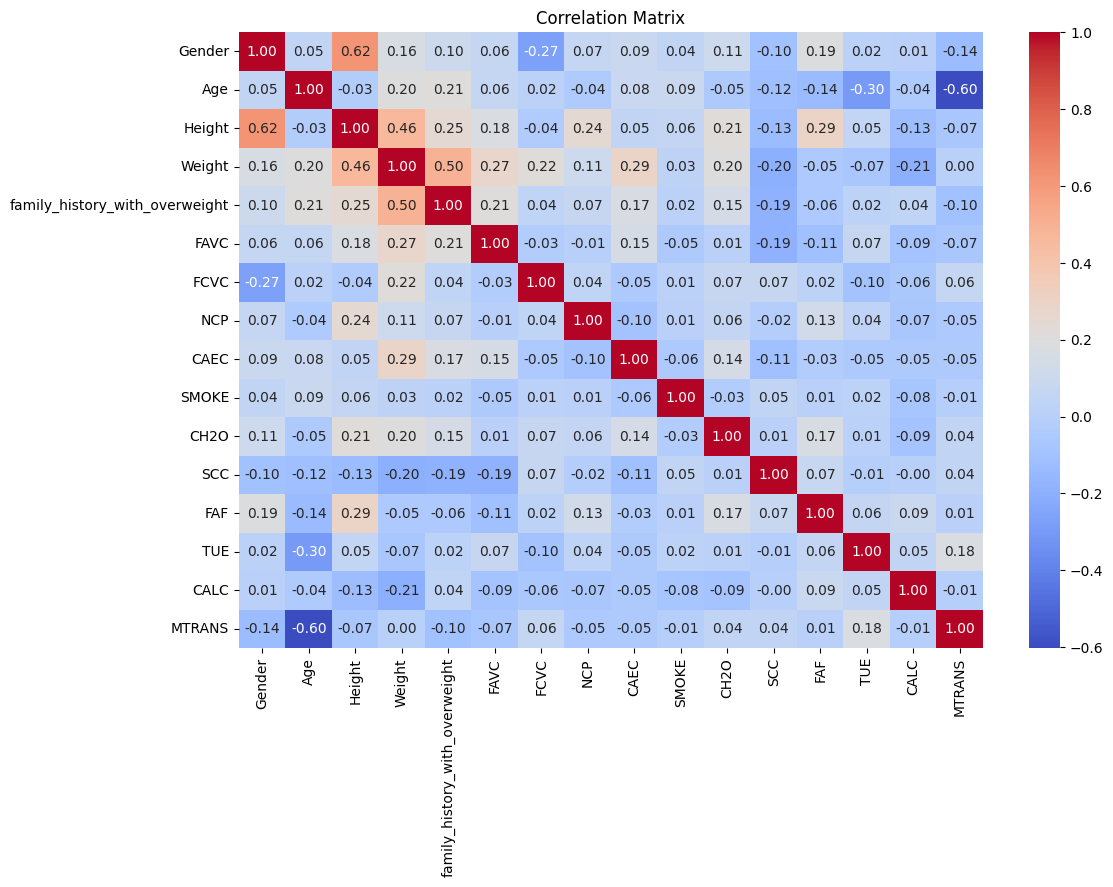

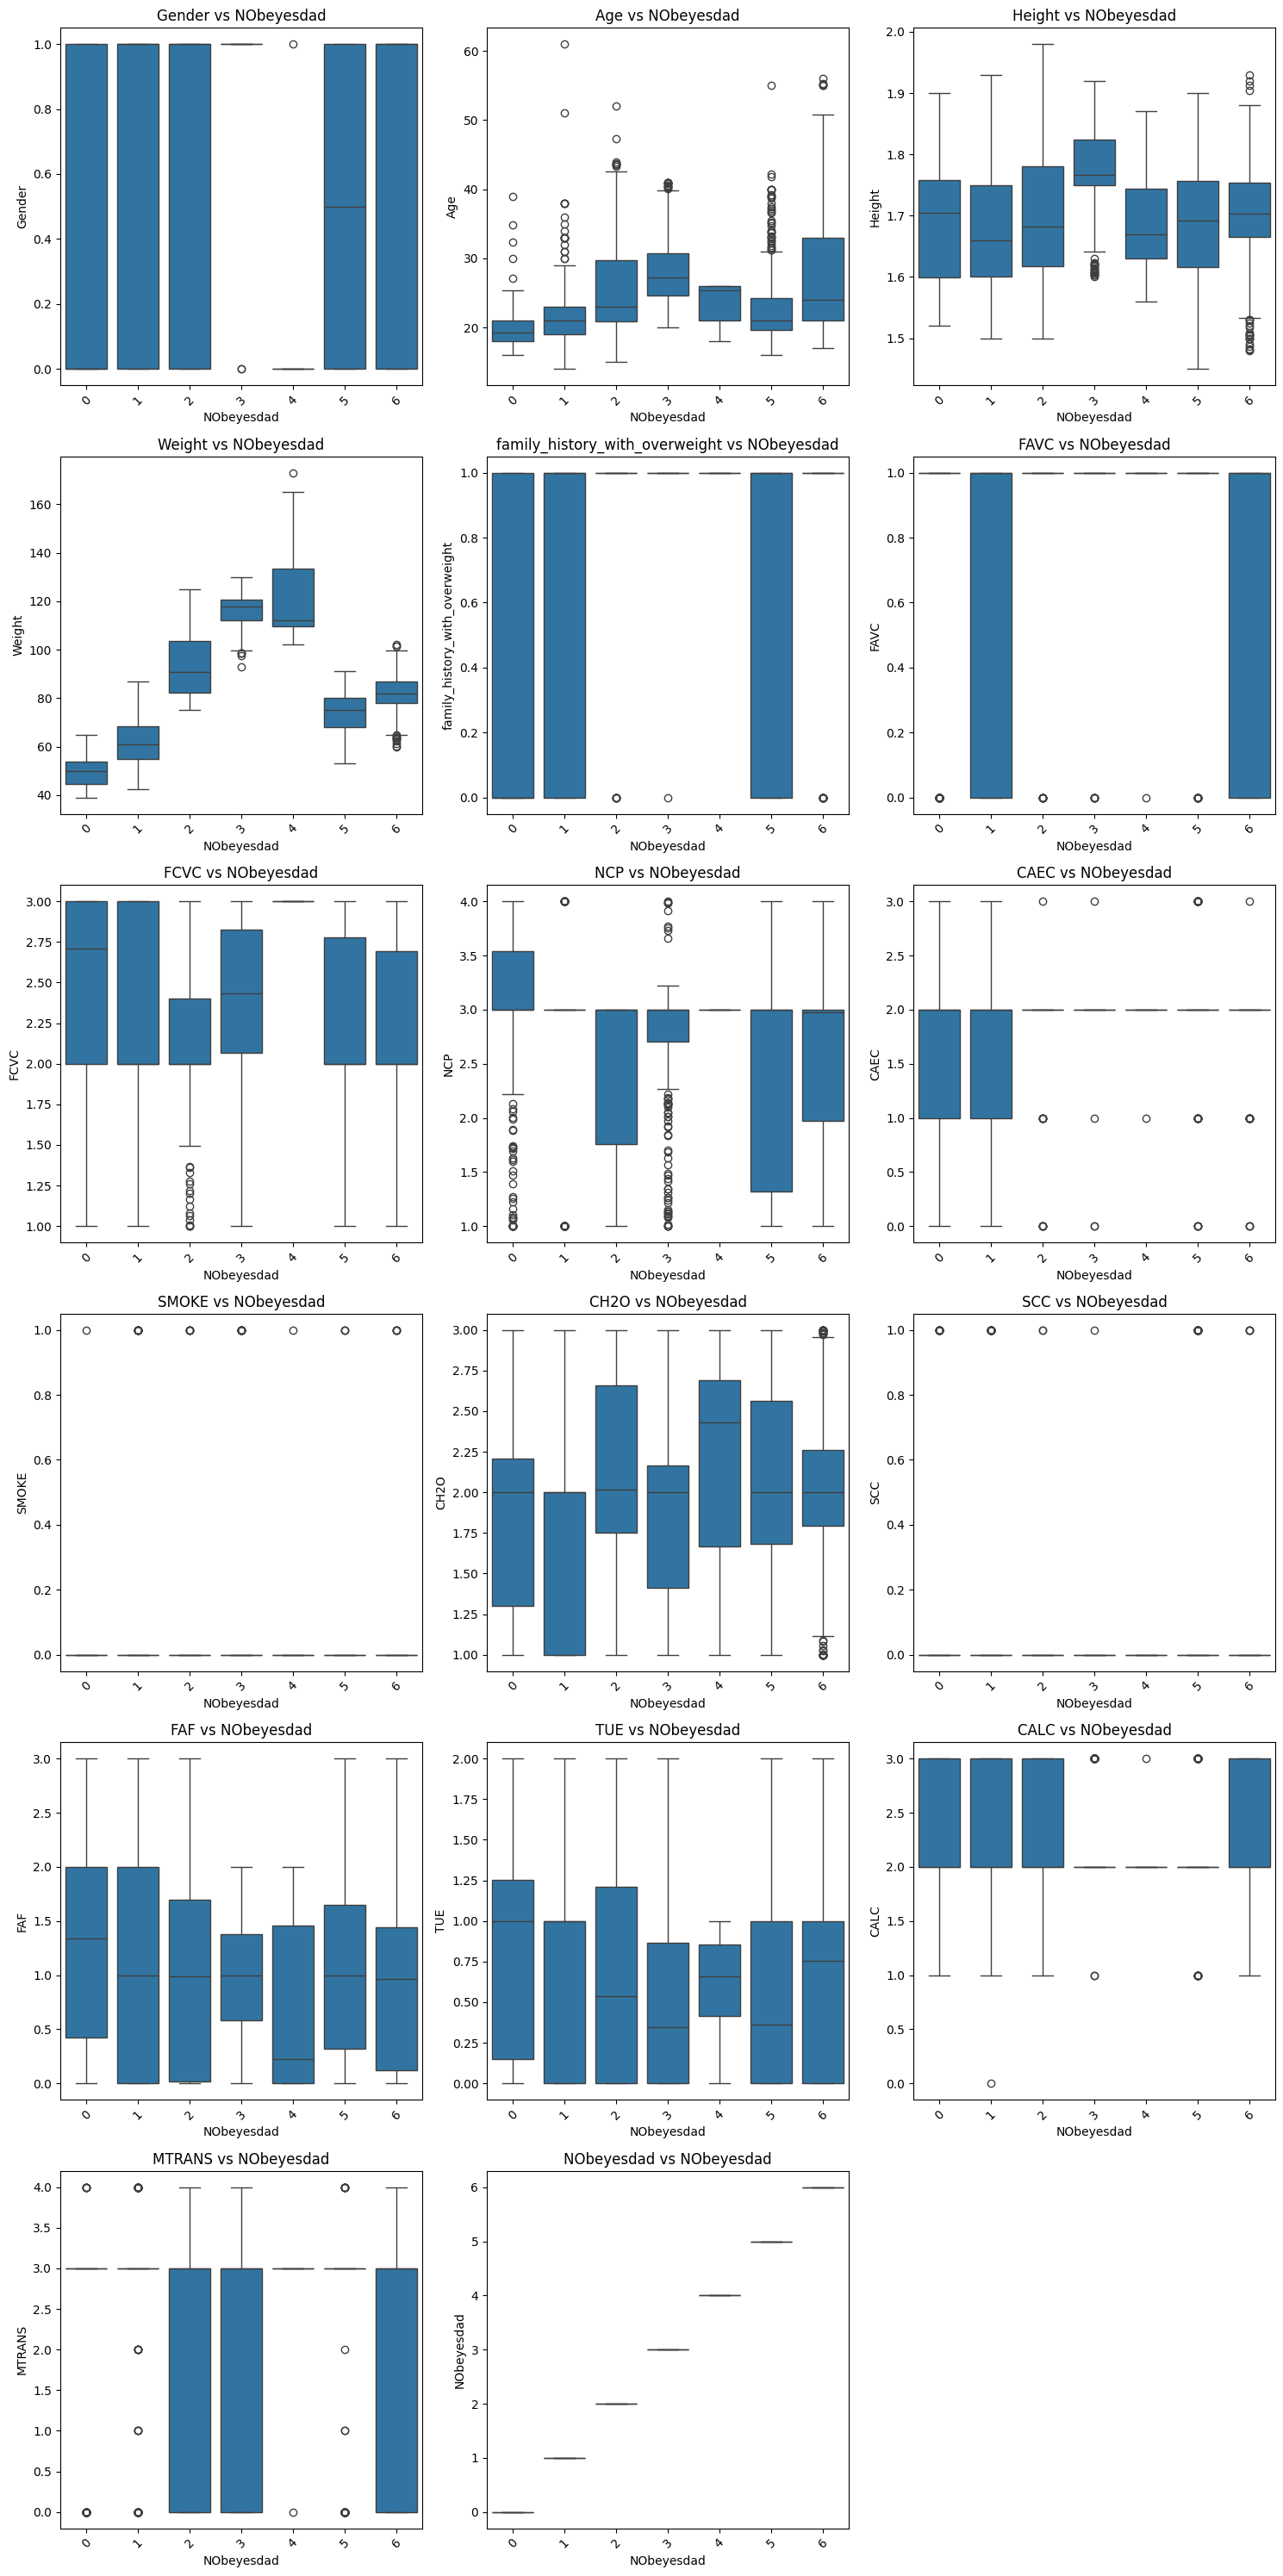

In [48]:
#HEATMAP 
plt.figure(figsize=(12, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

#BOXPLOT 
numerical_features = df.select_dtypes(include=['int64','float64']).columns

num_features = len(numerical_features)
cols = 3
rows = (num_features // cols) + (num_features % cols > 0)

plt.figure(figsize=(15, 5*rows))
for i, feature in enumerate(numerical_features):
    plt.subplot(rows, cols, i+1)
    sns.boxplot(x='NObeyesdad', y=feature, data=df)
    plt.title(f'{feature} vs NObeyesdad')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# K-Nearest Neighbors (KNN) Classifier 

### Model Implentation : 
Instead of using the pre-built KNN classifier from "scikit-learn", we implemented a custom KNN algorithm ("MyKNN").

The model works as follows:
- Stores training data during "fit()"".
- For each test sample, calculates distances (Euclidean or Manhattan).
- Finds the "k" nearest neighbors.
- Assigns the most frequent class among them.
 
We trained the model using "k=3" and distance metric = Manhattan. because it gave the best fit 



In [49]:
class MyKNN:
    def __init__(self, k=7,distance="euclidean"):
        self.k = k
        self.distance = distance

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        y_pred = []
        for x in X_test:
            if self.distance == "euclidean":
                distances = np.linalg.norm(self.X_train - x, axis=1)
            elif self.distance == "manhattan":
                distances = np.sum(np.abs(self.X_train - x),axis=1)

            nearest_indices = np.argsort(distances)[:self.k]
            nearest_labels = self.y_train[nearest_indices]
            label = Counter(nearest_labels).most_common(1)[0][0]
            y_pred.append(label)
        return np.array(y_pred)

    def predict_proba(self, X_test):
        proba = []
        for x in X_test:
            if self.distance == "euclidean":
                distances = np.linalg.norm(self.X_train - x, axis=1)
            elif self.distance == "manhattan":
                distances = np.sum(np.abs(self.X_train - x), axis=1)

            nearest_indices = np.argsort(distances)[:self.k]
            nearest_labels = self.y_train[nearest_indices]
            
            # Calculate probabilities based on class frequencies in neighbors
            class_counts = Counter(nearest_labels)
            total_neighbors = len(nearest_labels)
            class_probs = []
            
            for class_label in np.unique(self.y_train):
                class_probs.append(class_counts.get(class_label, 0) / total_neighbors)
            proba.append(class_probs)
        
        return np.array(proba)

In [50]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

##### Cross - Validation: 
Before we conducted the final model evaluation, we employed cross-validation to demonstrate our results were consistent and not solely reliant on a single data split.

Cross validation is important because of our multiclass classification problem, our model configuration needed to be generalizable to all categories of obesity.

In [51]:
param_grid = {
    'k': [3, 5, 7, 9, 11],
    'distance': ['euclidean', 'manhattan']
}
best_score = 0
best_params = {}
k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nPerforming Grid Search with Cross-Validation...")
for k in param_grid['k']:
    for distance in param_grid['distance']:
        fold_scores = []
        
        for train_idx, val_idx in k_fold.split(X_train, y_train):
            X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
            
            model = MyKNN(k=k, distance=distance)
            model.fit(X_fold_train, y_fold_train)
            y_fold_pred = model.predict(X_fold_val)
            score = accuracy_score(y_fold_val, y_fold_pred)
            fold_scores.append(score)
        
        mean_score = np.mean(fold_scores)
        print(f"k={k}, distance={distance}: Accuracy = {mean_score:.4f}")
        
        if mean_score > best_score:
            best_score = mean_score
            best_params = {'k': k, 'distance': distance}

print(f"\nBest Parameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")


Performing Grid Search with Cross-Validation...
k=3, distance=euclidean: Accuracy = 0.7840
k=3, distance=manhattan: Accuracy = 0.8449
k=5, distance=euclidean: Accuracy = 0.7759
k=5, distance=manhattan: Accuracy = 0.8422
k=7, distance=euclidean: Accuracy = 0.7583
k=7, distance=manhattan: Accuracy = 0.8267
k=9, distance=euclidean: Accuracy = 0.7488
k=9, distance=manhattan: Accuracy = 0.8152
k=11, distance=euclidean: Accuracy = 0.7332
k=11, distance=manhattan: Accuracy = 0.7962

Best Parameters: {'k': 3, 'distance': 'manhattan'}
Best Cross-Validation Accuracy: 0.8449


##### Traning the Model 
The following optimized parameters and process were utilized for the K-Nearest Neighbors classifier training process: 

Algorithm: K-Nearest Neighbors with a value of k=3

Distance metric: Manhattan distance 

Training Set: 70% of the dataset 

Validation: A test set of 30%, random_state=42 for reproduction 

Data Scaling: MinMaxScaler used to bound all features to the [0,1] range

In [52]:
final_model = MyKNN(k=best_params['k'], distance=best_params['distance'])
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

### Model Evaluation 
We evaluated the model using several metrics:
 
- Accuracy: Overall correctness of predictions.
- F1 Score: Harmonic mean of precision and recall.
- Recall: Ability to correctly identify true positives.
- Precision: Accuracy of positive predictions.
- Confusion Matrix: Detailed breakdown of predicted vs. actual classes.
 
The confusion matrix heatmap provides insights into misclassifications across categories.

Accuracy: 0.8580
F1 Score: 0.8554
Recall: 0.8580
Precision: 0.8564
Confusion Matrix:
 [[79  5  0  0  0  1  1]
 [12 57  8  0  0  7  9]
 [ 1  2 92  2  0  2  3]
 [ 0  0  2 85  0  0  1]
 [ 0  1  0  0 97  0  0]
 [ 2  9  3  0  0 67  7]
 [ 0  2  3  1  1  5 67]]
Type of onfusion matrix: <class 'numpy.ndarray'>


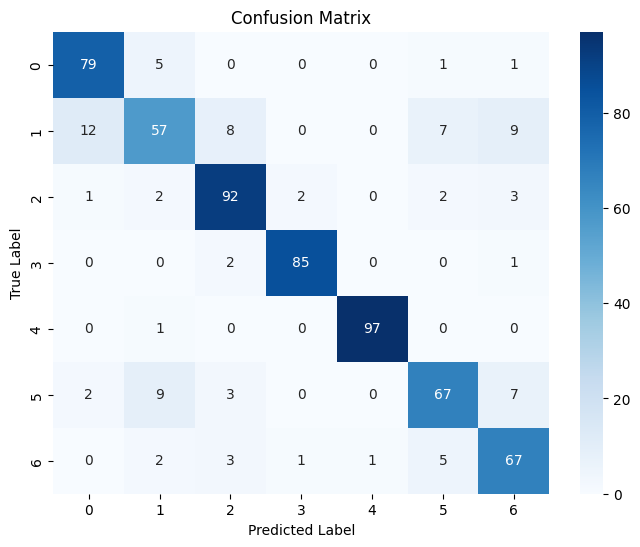

In [53]:
conf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted') 
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred,average = "weighted")
precision = precision_score(y_test,y_pred,average = "weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
#Building confusion matrix:

print("Confusion Matrix:\n", conf_matrix)
print("Type of onfusion matrix:", type(conf_matrix))
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


We used the One-vs-Rest (OvR) strategy for ROC curve and AUC generation in the context of multiclass classification. The classification model exhibited good discrimination across all seven obesity categories, consistently producing high AUC scores (typically >0.95) for each category against all others.

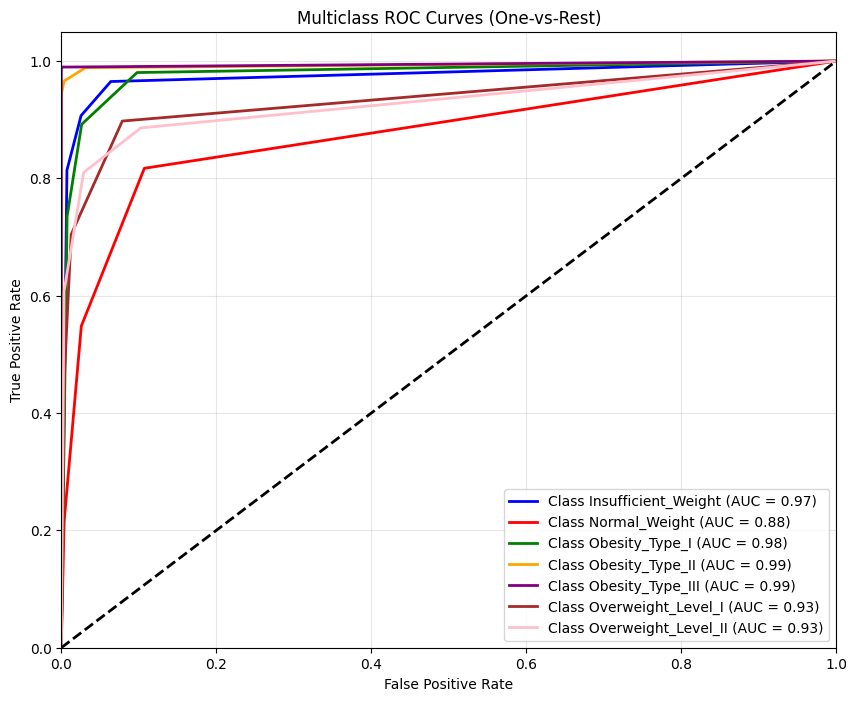

Macro-average AUC: 0.9540


In [54]:
y_proba = final_model.predict_proba(X_test)

# Calculate ROC curve and AUC for each class
n_classes = len(np.unique(y))
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)], 
             lw=2, label=f'Class {le_target.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
macro_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
print(f"Macro-average AUC: {macro_auc:.4f}")

# Model Saving
Finally, we saved the trained model using the "pickle" library so that it can be reused without retraining.

In [55]:
import pickle
pickle.dump(model, open('modelnew.pkl','wb'))

# Sample Prediction
We tested the model with a new sample containing 16 feature values.  

Before prediction, we have to make sure to use the encoded values instead of the actual values.

In [56]:
model = pickle.load(open('modelnew.pkl','rb'))
sample = [0, 21, 1.62, 64, 1, 0, 2, 3, 2, 0, 2, 0, 1, 1, 3, 3]  
print(model.predict([sample]))

[4]


# Model Interpretation 
### Feature Importance: 
Despite the absence of involvement of feature importance scores with KNN, we were able to utilize correlation analysis, to determine the main lead of the obesity classification. We found the strongest correlates to the target classes were Weight, CAEC and Family History with Overweight. 

In [57]:
correlation_matrix = df.corr()
target_correlations = correlation_matrix['NObeyesdad'].abs().sort_values(ascending=False)

print("Top features correlated with obesity levels:")
print(target_correlations.head(17))

Top features correlated with obesity levels:
NObeyesdad                        1.000000
Weight                            0.387643
CAEC                              0.327295
family_history_with_overweight    0.313667
Age                               0.236170
CALC                              0.134632
FAF                               0.129564
CH2O                              0.108868
NCP                               0.092616
TUE                               0.069448
SCC                               0.050679
MTRANS                            0.046202
FAVC                              0.044582
Height                            0.038986
Gender                            0.024908
SMOKE                             0.023256
FCVC                              0.018522
Name: NObeyesdad, dtype: float64


# Discuss the Results 

With excellent accuracy ratings, the K-Nearest Neighbors implementation demonstrated strong classification performance across all seven obesity categories. This illustrates shows how health outcomes may be meaningfully separated in the feature space.

**Analysis of the Contribution and Feature**
Through feature correlations and an evaluation of the model's performance, a number of characteristics showed a significant trend.

1) Physiological markers:  In the models, height and weight were regularly used as important differentiators.  This is consistent with clinical practice, where the established indicator of obesity is body mass index (BMI).

2) Genetic susceptibility:  In our analysis, the variable Family_history_with_overweight was a significant predictor of weight, supporting the body of medical data that obesity is inherited.

3) Lifestyle Factors: It has been suggested that daily activity patterns have an influence on health outcomes. The frequency of physical activity (FAF) and the modes of transportation utilized (MTRANS) have emerged as important markers of lifestyle behavior.

4) Dietary Patterns: The accuracy of the classification system was informed by dietary pattern indicators, such as calories from foods with high energy density (FAVC), consumption of vegetables (FCVC), and eating in between meals (CAEC), which supported the notion that nutritional habits are significant factors.

**Technical Implementation Success**

We had success with our technical implementation.

Label Encoding worked efficiently and effectively with all categorical variables.

The MinMaxScaler normalization yielded the expected, best performance with our distance KNN algorithm.

The random_state=42 70-30 train-test split consistently obtained reliable, reproducible results.

Reliable, comprehensive evaluation metrics indicated balanced performance across each obesity category.

**Clinical Significance and Constraints**

Although the model performs well statistically, there are still important limitations: 

Self-reported lifestyle data could cause measurement bias. 

Clinical comprehensiveness is limited without biochemical markers.

KNN relies on a distance-based approach, making the model challenging to interpret.

The findings support the idea that multifactorial categorizing of obesity classification incorporates physiological measurements with behavioral & lifestyle measurement, potentially applicable for decision support in preventative health care, though further clinical validation would increase applicability to a real world setting.